In [1]:
import os, sys, warnings, logging, json, time, gc
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Type, Union
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import joblib
import optuna

import torch
import torch.nn as nn
import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.policies import ActorCriticPolicy
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from stable_baselines3.common.callbacks import BaseCallback, CallbackList
from stable_baselines3.common.vec_env import DummyVecEnv
from sklearn.preprocessing import RobustScaler

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Paths ─────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path('.')
CONFIGS_DIR  = PROJECT_ROOT / 'configs'
MODELS_DIR   = PROJECT_ROOT / 'models'
RESULTS_DIR  = PROJECT_ROOT / 'results'
RESULTS_HPO  = RESULTS_DIR / 'hpo'
PLOTS_DIR    = RESULTS_DIR / 'plots'
for d in [MODELS_DIR, RESULTS_HPO, PLOTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Device + seed ─────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED   = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print(f'Device: {DEVICE}')

# ── Load configs ──────────────────────────────────────────────────────────
with open(CONFIGS_DIR / 'environment.yaml') as f:
    ENV_CONFIG = yaml.safe_load(f)
with open(CONFIGS_DIR / 'features.yaml') as f:
    FEAT_CONFIG = yaml.safe_load(f)

ALL_FEATURES    = FEAT_CONFIG['all_features']
REGIME_FEATURES = FEAT_CONFIG['regime_features']
LOOKBACK        = FEAT_CONFIG['lookback_window']
N_FEATURES      = FEAT_CONFIG['n_features']
REGIME_IDX      = [ALL_FEATURES.index(f) for f in REGIME_FEATURES]

# ── Load data ─────────────────────────────────────────────────────────────
wti_df = pd.read_parquet(PROJECT_ROOT / 'data' / 'features' / 'WTI_Crude_Oil_features.parquet')
wti_df = wti_df.dropna(subset=ALL_FEATURES + ['log_return', 'close'])
print(f'WTI data: {len(wti_df)} rows | {wti_df.index[0].date()} to {wti_df.index[-1].date()}')

# ── Walk-forward splits ───────────────────────────────────────────────────
def make_wf_splits(df, train_years=3, test_years=1):
    dates = df.index.sort_values()
    start = dates[0]
    end   = dates[-1]
    splits = []
    t = start + pd.DateOffset(years=train_years)
    while t + pd.DateOffset(years=test_years) <= end + pd.DateOffset(days=1):
        splits.append({
            'train_start': str(start.date()),
            'train_end'  : str(t.date()),
            'test_start' : str(t.date()),
            'test_end'   : str(min(t + pd.DateOffset(years=test_years),
                                   end + pd.DateOffset(days=1)).date())
        })
        t += pd.DateOffset(years=test_years)
    return splits

WF_SPLITS = make_wf_splits(wti_df)
print(f'Walk-forward splits: {len(WF_SPLITS)}')
for i, s in enumerate(WF_SPLITS[:4]):
    print(f'  Split {i}: train {s["train_start"]} to {s["train_end"]} | test {s["test_start"]} to {s["test_end"]}')
if len(WF_SPLITS) > 4:
    print(f'  ... and {len(WF_SPLITS)-4} more')


C:\Users\anton\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\anton\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\anton\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Us

Device: cuda
WTI data: 4965 rows | 2005-12-21 to 2024-12-31
Walk-forward splits: 16
  Split 0: train 2005-12-21 to 2008-12-21 | test 2008-12-21 to 2009-12-21
  Split 1: train 2005-12-21 to 2009-12-21 | test 2009-12-21 to 2010-12-21
  Split 2: train 2005-12-21 to 2010-12-21 | test 2010-12-21 to 2011-12-21
  Split 3: train 2005-12-21 to 2011-12-21 | test 2011-12-21 to 2012-12-21
  ... and 12 more


In [2]:
from pathlib import Path
needed = [
    'configs/environment.yaml',
    'configs/features.yaml',
    'data/features/WTI_Crude_Oil_features.parquet',
]
for f in needed:
    p = Path(f)
    print(f'{"✓" if p.exists() else "✗ MISSING"} {f}')

✓ configs/environment.yaml
✓ configs/features.yaml
✓ data/features/WTI_Crude_Oil_features.parquet


In [3]:
class CommodityTradingEnv(gym.Env):
    metadata = {'render_modes': ['human']}

    def __init__(self, df, features, config, mode='train', scaler=None, render_mode=None):
        super().__init__()
        self.df = df.copy()
        self.features = features
        self.config = config
        self.mode = mode
        self.render_mode = render_mode
        missing = [f for f in features if f not in df.columns]
        if missing:
            raise ValueError(f'Missing features: {missing}')
        self.n_features = len(features)
        self.lookback = config['lookback_window']
        self.episode_length = config['episode_length']
        self.n_rows = len(df)
        self.min_rows = self.lookback + self.episode_length
        if self.n_rows < self.min_rows:
            raise ValueError(f'Need {self.min_rows} rows, got {self.n_rows}')
        if mode == 'train' or scaler is None:
            self.scaler = RobustScaler()
            self.scaler.fit(df[features].values)
        else:
            self.scaler = scaler
        scaled = self.scaler.transform(df[features].values)
        self.features_arr = np.clip(scaled, -config['clip_obs'], config['clip_obs']).astype(np.float32)
        self.close_arr  = df['close'].values.astype(np.float32)
        self.return_arr = df['log_return'].fillna(0).values.astype(np.float32)
        obs_dim = self.lookback * self.n_features + 5
        self.observation_space = gym.spaces.Box(
            low=-config['clip_obs'], high=config['clip_obs'],
            shape=(obs_dim,), dtype=np.float32)
        self.action_space = gym.spaces.Box(
            low=np.array([config['action_min']], dtype=np.float32),
            high=np.array([config['action_max']], dtype=np.float32),
            shape=(1,), dtype=np.float32)
        self._init_state()

    def _init_state(self):
        self.current_step = 0
        self.start_idx = 0
        self.portfolio_value = float(self.config['initial_capital'])
        self.cash = self.portfolio_value
        self.position = 0.0
        self.peak_value = self.portfolio_value
        self.total_costs = 0.0
        self.trade_count = 0
        self.return_history = []
        self.value_history  = [self.portfolio_value]
        self.action_history = []
        self.reward_history = []

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        max_start = self.n_rows - self.episode_length - self.lookback
        if self.mode == 'train':
            self.start_idx = int(self.np_random.integers(0, max(1, max_start)))
        else:
            self.start_idx = 0
        self._init_state()
        return self._get_observation(), self._get_info()

    def step(self, action):
        new_pos = float(np.clip(action[0], self.config['action_min'], self.config['action_max']))
        max_change = self.config['position_change_limit']
        delta = np.clip(new_pos - self.position, -max_change, max_change)
        new_pos = self.position + delta
        cost = self._compute_cost(self.position, new_pos)
        data_idx = self.start_idx + self.lookback + self.current_step
        market_ret = float(self.return_arr[min(data_idx, len(self.return_arr)-1)])
        port_ret = self.position * market_ret - cost
        new_val = self.portfolio_value * (1 + port_ret)
        self.position = new_pos
        self.portfolio_value = new_val
        self.peak_value = max(self.peak_value, new_val)
        self.total_costs += cost * self.portfolio_value
        self.trade_count += 1 if abs(delta) > 0.01 else 0
        reward = self._compute_reward(port_ret, cost)
        self.return_history.append(port_ret)
        self.value_history.append(self.portfolio_value)
        self.action_history.append(new_pos)
        self.reward_history.append(reward)
        self.current_step += 1
        truncated  = self.current_step >= self.episode_length
        terminated = self._check_termination()
        return self._get_observation(), reward, terminated, truncated, self._get_info()

    def _compute_cost(self, old_pos, new_pos):
        trade_size = abs(new_pos - old_pos)
        if trade_size < 1e-6:
            return 0.0
        cost = trade_size * (
            self.config['commission_per_trade'] +
            self.config['bid_ask_spread'] +
            self.config['slippage']
        )
        if self.current_step % 21 == 0 and abs(new_pos) > 0.01:
            cost += abs(new_pos) * self.config['roll_cost']
        return float(cost)

    def _compute_reward(self, port_ret, cost):
        cfg = self.config
        r_return = port_ret
        drawdown = self.portfolio_value / self.peak_value - 1 if self.peak_value > 0 else 0.0
        r_drawdown = min(drawdown, 0.0)
        r_transaction = -cost
        r_sharpe = 0.0
        w = cfg['sharpe_window']
        if len(self.return_history) >= w:
            rets = np.array(self.return_history[-w:])
            r_sharpe = np.clip(
                rets.mean() / (rets.std() + 1e-10) * np.sqrt(252/w),
                -5.0, 5.0)
        reward = (
            cfg['w_return']      * r_return +
            cfg['w_drawdown']    * r_drawdown +
            cfg['w_transaction'] * r_transaction +
            cfg['w_sharpe']      * r_sharpe * 0.01
        ) * cfg['reward_scaling']
        return float(reward)

    def _check_termination(self):
        if self.peak_value <= 0:
            return True
        return (self.portfolio_value / self.peak_value - 1) < self.config['max_drawdown_limit']

    def _get_observation(self):
        start = self.start_idx + self.current_step
        end   = start + self.lookback
        end   = min(end, len(self.features_arr))
        start = max(0, end - self.lookback)
        feat_window = self.features_arr[start:end]
        if len(feat_window) < self.lookback:
            pad = np.zeros((self.lookback - len(feat_window), self.n_features), dtype=np.float32)
            feat_window = np.vstack([pad, feat_window])
        drawdown = self.portfolio_value / self.peak_value - 1 if self.peak_value > 0 else 0.0
        log_pnl  = np.log(self.portfolio_value / self.config['initial_capital'] + 1e-10)
        port_state = np.array([
            self.position,
            np.clip(drawdown, -1.0, 0.0),
            np.clip(log_pnl, -5.0, 5.0),
            self.current_step / self.episode_length,
            np.clip(self.total_costs / self.config['initial_capital'], 0, 0.1)
        ], dtype=np.float32)
        return np.concatenate([feat_window.flatten(), port_state]).astype(np.float32)

    def _get_info(self):
        dd = self.portfolio_value / self.peak_value - 1 if self.peak_value > 0 else 0.0
        tr = self.portfolio_value / self.config['initial_capital'] - 1
        sharpe = 0.0
        if len(self.return_history) >= self.config['sharpe_window']:
            rets = np.array(self.return_history)
            sharpe = rets.mean() / (rets.std() + 1e-10) * np.sqrt(252)
        return {
            'step': self.current_step, 'portfolio_value': self.portfolio_value,
            'position': self.position, 'total_return': tr,
            'drawdown': dd, 'sharpe': sharpe,
            'total_costs': self.total_costs, 'trade_count': self.trade_count
        }

    def get_episode_metrics(self):
        values  = np.array(self.value_history)
        returns = np.array(self.return_history)
        if len(returns) < 2:
            return {}
        total_return = values[-1] / values[0] - 1
        n_days    = len(returns)
        ann_ret   = (1 + total_return) ** (252 / n_days) - 1
        ann_vol   = returns.std() * np.sqrt(252)
        sharpe    = ann_ret / (ann_vol + 1e-10)
        peak      = np.maximum.accumulate(values)
        dd        = (values - peak) / (peak + 1e-10)
        max_dd    = dd.min()
        calmar    = ann_ret / (abs(max_dd) + 1e-10)
        neg_rets  = returns[returns < 0]
        down_std  = neg_rets.std() * np.sqrt(252) if len(neg_rets) > 0 else 1e-10
        sortino   = ann_ret / (down_std + 1e-10)
        win_rate  = (returns > 0).mean()
        return {
            'total_return': float(total_return), 'ann_return': float(ann_ret),
            'ann_vol': float(ann_vol), 'sharpe': float(sharpe),
            'max_drawdown': float(max_dd), 'calmar': float(calmar),
            'sortino': float(sortino), 'win_rate': float(win_rate),
            'total_costs': float(self.total_costs), 'trade_count': int(self.trade_count),
            'episode_length': int(len(returns))
        }

    def render(self):
        pass

    def close(self):
        pass


class WalkForwardEnvFactory:
    def __init__(self, df, features, splits, config):
        self.df = df
        self.features = features
        self.splits = splits
        self.config = config

    def get_split(self, split_idx):
        split = self.splits[split_idx]
        train_df = self.df[
            (self.df.index >= split['train_start']) &
            (self.df.index <  split['train_end'])
        ].copy()
        test_df = self.df[
            (self.df.index >= split['test_start']) &
            (self.df.index <  split['test_end'])
        ].copy()
        scaler = RobustScaler()
        scaler.fit(train_df[self.features].values)
        test_config  = dict(self.config)
        train_config = dict(self.config)
        min_test_ep  = len(test_df) - self.config['lookback_window']
        min_train_ep = len(train_df) - self.config['lookback_window']
        if min_test_ep < self.config['episode_length']:
            if min_test_ep < 20:
                return None, None, None
            test_config['episode_length'] = min_test_ep
        if min_train_ep < self.config['episode_length']:
            train_config['episode_length'] = min_train_ep
        train_env = CommodityTradingEnv(train_df, self.features, train_config, 'train', scaler)
        test_env  = CommodityTradingEnv(test_df,  self.features, test_config,  'test',  scaler)
        return train_env, test_env, scaler

    def n_splits(self):
        return len(self.splits)


print('CommodityTradingEnv and WalkForwardEnvFactory defined.')


CommodityTradingEnv and WalkForwardEnvFactory defined.


In [4]:
class RegimeGatingLayer(nn.Module):
    """Learns to gate latent features based on 4 regime signals."""

    def __init__(self, n_regime: int, latent_dim: int):
        super().__init__()
        self.gate = nn.Sequential(
            nn.Linear(n_regime, latent_dim * 2),
            nn.Tanh(),
            nn.Linear(latent_dim * 2, latent_dim),
            nn.Sigmoid(),          # γ ∈ (0,1)^d
        )
        # Initialise close to 1 so early training is close to unregularised PPO
        nn.init.zeros_(self.gate[-2].bias)
        nn.init.zeros_(self.gate[-2].weight)

    def forward(self, regime_signals: torch.Tensor, latent: torch.Tensor) -> torch.Tensor:
        gamma = self.gate(regime_signals)          # (B, latent_dim)
        # Bias toward 1: γ' = 0.5·γ + 0.5  ∈ (0.5, 1)
        gamma = 0.5 * gamma + 0.5
        return latent * gamma


class ResidualBlock(nn.Module):
    """Pre-norm residual block: LayerNorm → Linear → Activation → Linear + skip."""

    def __init__(self, dim: int, dropout: float = 0.1):
        super().__init__()
        self.block = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, dim),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.block(x)


class RegimeAwareExtractor(BaseFeaturesExtractor):
    """
    Custom SB3 feature extractor for ARA-PPO.

    Architecture
    ─────────────
    1. Flatten raw observation
    2. Main trunk: Linear(obs) → ResidualBlock × 2  → latent ∈ R^256
    3. Regime trunk: reads regime features → gating γ ∈ (0.5,1)^256
    4. Gated latent: z = latent * γ
    5. Return (z, regime_signals) packed into a flat vector
       SB3 expects a flat tensor; we cat z ‖ regime_signals.
    """

    # Indices of the 4 regime features inside the LAST lookback step
    # The obs layout is: feat_window.flatten() ‖ port_state (5)
    # feat_window[lookback-1, :] starts at index (lookback-1)*n_features

    def __init__(
        self,
        observation_space: gym.Space,
        latent_dim: int = 256,
        n_regime: int = 4,
        lookback: int = 60,
        n_features: int = 40,
        regime_idx: List[int] = None,
        dropout: float = 0.1,
    ):
        # features_dim is what SB3 passes to actor/critic heads
        features_dim = latent_dim + n_regime
        super().__init__(observation_space, features_dim=features_dim)

        self.latent_dim   = latent_dim
        self.n_regime     = n_regime
        self.lookback     = lookback
        self.n_features   = n_features
        # Offset to last-step features in flattened obs
        self._last_step_offset = (lookback - 1) * n_features
        self._regime_idx = regime_idx if regime_idx is not None else list(range(n_regime))

        obs_dim = int(np.prod(observation_space.shape))

        # ── Main trunk ────────────────────────────────────────────────────────────
        self.input_proj = nn.Sequential(
            nn.Linear(obs_dim, latent_dim),
            nn.LayerNorm(latent_dim),
            nn.ELU(),
        )
        self.res_blocks = nn.Sequential(
            ResidualBlock(latent_dim, dropout),
            ResidualBlock(latent_dim, dropout),
        )
        self.post_norm = nn.LayerNorm(latent_dim)

        # ── Regime trunk & gating ─────────────────────────────────────────────────
        self.regime_gating = RegimeGatingLayer(n_regime, latent_dim)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
                nn.init.zeros_(m.bias)

    def _extract_regime(self, obs: torch.Tensor) -> torch.Tensor:
        """Extract the 4 regime features from the most-recent timestep."""
        regime_vals = []
        for ri in self._regime_idx:
            col_idx = self._last_step_offset + ri
            regime_vals.append(obs[:, col_idx:col_idx+1])
        return torch.cat(regime_vals, dim=-1)   # (B, 4)

    def forward(self, observations: torch.Tensor) -> torch.Tensor:
        regime_signals = self._extract_regime(observations)
        z = self.input_proj(observations)
        z = self.res_blocks(z)
        z = self.post_norm(z)
        z = self.regime_gating(regime_signals, z)         # gated latent
        return torch.cat([z, regime_signals], dim=-1)     # (B, latent+4)



class AdaptiveClipCallback(BaseCallback):
    """
    Modification 2: Adapt PPO clip_range based on regime_vol.

    At each rollout, reads regime_vol from the collected observations
    and adjusts clip_range for the next update.

    Parameters
    ----------
    eps_base   : float  – baseline clip value (default 0.2)
    alpha      : float  – sensitivity to regime_vol (default 0.5)
    eps_min    : float  – floor (default 0.05)
    eps_max    : float  – ceiling (default 0.4)
    regime_obs_idx : int – position of regime_vol in the flattened observation
    """

    def __init__(
        self,
        eps_base: float = 0.2,
        alpha: float = 0.5,
        eps_min: float = 0.05,
        eps_max: float = 0.40,
        regime_obs_idx: int = None,
        verbose: int = 0,
    ):
        super().__init__(verbose)
        self.eps_base       = eps_base
        self.alpha          = alpha
        self.eps_min        = eps_min
        self.eps_max        = eps_max
        self.regime_obs_idx = regime_obs_idx  # set externally if known
        self.clip_history   = []

    def _on_rollout_end(self) -> bool:
        """Called after rollout buffer is filled, before policy update."""
        # Read regime_vol from rollout buffer observations
        obs = self.model.rollout_buffer.observations   # (n_steps, n_envs, obs_dim)
        if self.regime_obs_idx is not None and obs is not None:
            regime_vol = obs[:, :, self.regime_obs_idx].mean()  # scalar
        else:
            # Fall-back: use last-step regime feature from extractor if available
            regime_vol = 0.0

        # Normalise: regime_vol is RobustScaler output, typically in [-5,5]
        # Map to [0,1] via sigmoid
        regime_vol_norm = float(torch.sigmoid(torch.tensor(float(regime_vol))).item())

        new_eps = self.eps_base * (1.0 + self.alpha * regime_vol_norm)
        new_eps = float(np.clip(new_eps, self.eps_min, self.eps_max))

        # SB3 clip_range is a callable; wrap scalar in a lambda
        self.model.clip_range = lambda _: new_eps
        self.clip_history.append(new_eps)

        if self.verbose >= 2:
            logger.info(f'AdaptiveClip: regime_vol={regime_vol:.3f} → ε={new_eps:.4f}')
        return True

    def _on_step(self) -> bool:
        return True




class RegimeDecomposedValueNet(nn.Module):
    """
    Modification 3: V(s) = V_base(s) + alpha_regime * V_regime(s)

    Installed as policy.value_net by ARAPPOPolicy._build().
    Input: full feature vector from extractor (latent + regime signals).
    """

    def __init__(self, features_dim: int, n_regime: int = 4, hidden: int = 128):
        super().__init__()
        self.v_base = nn.Sequential(
            nn.Linear(features_dim, hidden), nn.ELU(),
            nn.Linear(hidden, hidden // 2), nn.ELU(),
            nn.Linear(hidden // 2, 1),
        )
        self.v_regime = nn.Sequential(
            nn.Linear(n_regime, hidden // 2), nn.Tanh(),
            nn.Linear(hidden // 2, hidden // 4), nn.Tanh(),
            nn.Linear(hidden // 4, 1),
        )
        self.alpha_regime = nn.Parameter(torch.tensor(0.1))
        self.n_regime = n_regime
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=1.0)
                nn.init.zeros_(m.bias)

    def forward(self, features: torch.Tensor) -> torch.Tensor:
        regime_signals = features[:, -self.n_regime:]
        alpha = torch.clamp(self.alpha_regime, 0.0, 1.0)
        return self.v_base(features) + alpha * self.v_regime(regime_signals)


class _ARAMlpExtractorWrapper(nn.Module):
    """
    Wraps actor body + critic pass-through for SB3's ActorCriticPolicy.

    Actor path  : features -> actor_body -> latent_pi (size actor_hidden//2)
                  SB3 action_net = Linear(latent_pi, action_dim)
    Critic path : features -> pass-through (latent_vf = features_dim)
                  ARAPPOPolicy._build() replaces value_net with RegimeDecomposedValueNet
    """

    def __init__(self, features_dim: int, n_regime: int, actor_hidden: int):
        super().__init__()
        self.actor_body = nn.Sequential(
            nn.Linear(features_dim, actor_hidden), nn.ELU(),
            nn.Linear(actor_hidden, actor_hidden // 2), nn.ELU(),
        )
        self.latent_dim_pi = actor_hidden // 2  # SB3 sizes action_net from this
        self.latent_dim_vf = features_dim        # pass-through; replaced value_net reads this
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
                nn.init.zeros_(m.bias)

    def forward(self, features: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        return self.actor_body(features), features

    def forward_actor(self, features: torch.Tensor) -> torch.Tensor:
        return self.actor_body(features)

    def forward_critic(self, features: torch.Tensor) -> torch.Tensor:
        return features   # RegimeDecomposedValueNet is installed as value_net



class ARAPPOPolicy(ActorCriticPolicy):
    """
    Full ARA-PPO policy wiring all three modifications:

      Mod 1  -- RegimeAwareExtractor (features_extractor)
      Mod 2  -- AdaptiveClipCallback (wired externally)
      Mod 3  -- RegimeDecomposedValueNet injected as value_net in _build()

    Override strategy:
      _build_mlp_extractor  : installs _ARAMlpExtractorWrapper
      _build                : calls super() then replaces value_net with Mod 3
    """

    def __init__(
        self,
        observation_space,
        action_space,
        lr_schedule,
        latent_dim: int = 256,
        n_regime: int = 4,
        lookback: int = 60,
        n_features: int = 40,
        regime_idx: List[int] = None,
        actor_hidden: int = 128,
        critic_hidden: int = 128,
        dropout: float = 0.1,
        **kwargs,
    ):
        self._ara_latent_dim  = latent_dim
        self._ara_n_regime    = n_regime
        self._ara_actor_h     = actor_hidden
        self._ara_critic_h    = critic_hidden

        kwargs['features_extractor_class']  = RegimeAwareExtractor
        kwargs['features_extractor_kwargs'] = dict(
            latent_dim  = latent_dim,
            n_regime    = n_regime,
            lookback    = lookback,
            n_features  = n_features,
            regime_idx  = regime_idx if regime_idx is not None else list(range(n_regime)),
            dropout     = dropout,
        )
        kwargs['net_arch'] = dict(pi=[], vf=[])
        super().__init__(observation_space, action_space, lr_schedule, **kwargs)

    def _build_mlp_extractor(self) -> None:
        fd = self._ara_latent_dim + self._ara_n_regime
        self.mlp_extractor = _ARAMlpExtractorWrapper(
            features_dim  = fd,
            n_regime      = self._ara_n_regime,
            actor_hidden  = self._ara_actor_h,
        )

    def _build(self, lr_schedule) -> None:
        """
        Call SB3's _build() to set up action_net / log_std / optimizer,
        then replace value_net with RegimeDecomposedValueNet (Mod 3).
        """
        super()._build(lr_schedule)
        fd = self._ara_latent_dim + self._ara_n_regime
        # Replace SB3's Linear(features_dim, 1) with Mod 3 decomposed value net
        self.value_net = RegimeDecomposedValueNet(
            features_dim = fd,
            n_regime     = self._ara_n_regime,
            hidden       = self._ara_critic_h,
        )



class EpisodeMetricsCallback(BaseCallback):
    """
    Collects per-episode metrics from the info dict and logs them to TensorBoard.
    Also maintains running lists for later plotting.
    """

    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.episode_sharpes  = []
        self.episode_returns  = []
        self.episode_drawdowns= []
        self._ep_reward       = 0.0
        self._ep_steps        = 0

    def _on_step(self) -> bool:
        self._ep_reward += float(self.locals['rewards'][0])
        self._ep_steps  += 1

        dones = self.locals.get('dones', [False])
        infos = self.locals.get('infos', [{}])
        if dones[0]:
            info = infos[0]
            sharpe  = info.get('sharpe', 0.0)
            ret     = info.get('total_return', 0.0)
            dd      = info.get('drawdown', 0.0)
            self.episode_sharpes.append(sharpe)
            self.episode_returns.append(ret)
            self.episode_drawdowns.append(dd)
            self.logger.record('episode/sharpe',   sharpe)
            self.logger.record('episode/return',   ret)
            self.logger.record('episode/drawdown', dd)
            self.logger.record('episode/reward',   self._ep_reward)
            self._ep_reward = 0.0
            self._ep_steps  = 0
        return True



print('All ARA-PPO classes defined.')


All ARA-PPO classes defined.


In [5]:
ARA_PPO_HPARAMS_DEFAULT = {
    'learning_rate': 3e-4, 'n_steps': 512, 'batch_size': 64,
    'n_epochs': 10, 'gamma': 0.99, 'gae_lambda': 0.95,
    'clip_range': 0.2, 'clip_range_vf': None,
    'normalize_advantage': True, 'ent_coef': 0.01,
    'vf_coef': 0.5, 'max_grad_norm': 0.5,
    'latent_dim': 256, 'n_regime': 4,
    'actor_hidden': 128, 'critic_hidden': 128, 'dropout': 0.1,
    'eps_base': 0.2, 'eps_alpha': 0.5, 'eps_min': 0.05, 'eps_max': 0.40,
}


def make_ara_ppo(
    env,
    hparams=None,
    env_config=None,
    lookback=None,
    n_features=None,
    regime_idx=None,
    seed=SEED,
    verbose=0,
):
    hp  = {**ARA_PPO_HPARAMS_DEFAULT, **(hparams or {})}
    lk  = lookback   if lookback   is not None else LOOKBACK
    nf  = n_features if n_features is not None else N_FEATURES
    ri  = regime_idx if regime_idx is not None else REGIME_IDX

    regime_vol_feat_pos = ALL_FEATURES.index('regime_vol')
    regime_obs_idx = (lk - 1) * nf + regime_vol_feat_pos

    policy_kwargs = dict(
        latent_dim=hp['latent_dim'], n_regime=hp['n_regime'],
        lookback=lk, n_features=nf, regime_idx=ri,
        actor_hidden=hp['actor_hidden'], critic_hidden=hp['critic_hidden'],
        dropout=hp['dropout'],
    )

    # Use closure-safe lambda
    vec_env = DummyVecEnv([lambda e=env: e])

    model = PPO(
        policy=ARAPPOPolicy, env=vec_env,
        learning_rate=hp['learning_rate'], n_steps=hp['n_steps'],
        batch_size=hp['batch_size'], n_epochs=hp['n_epochs'],
        gamma=hp['gamma'], gae_lambda=hp['gae_lambda'],
        clip_range=hp['clip_range'], clip_range_vf=hp['clip_range_vf'],
        normalize_advantage=hp['normalize_advantage'],
        ent_coef=hp['ent_coef'], vf_coef=hp['vf_coef'],
        max_grad_norm=hp['max_grad_norm'],
        policy_kwargs=policy_kwargs, seed=seed,
        device=DEVICE, verbose=verbose,
    )

    clip_cb = AdaptiveClipCallback(
        eps_base=hp['eps_base'], alpha=hp['eps_alpha'],
        eps_min=hp['eps_min'], eps_max=hp['eps_max'],
        regime_obs_idx=regime_obs_idx, verbose=verbose,
    )
    return model, clip_cb


# ── Smoke test ────────────────────────────────────────────────────────────
_df  = wti_df.iloc[:800].copy()
_env = CommodityTradingEnv(_df, ALL_FEATURES, ENV_CONFIG, mode='train')
_m, _ = make_ara_ppo(_env, verbose=0)
print(f'Smoke test passed. Params: {sum(p.numel() for p in _m.policy.parameters()):,}')
del _m, _env, _df
torch.cuda.empty_cache()
gc.collect()


Smoke test passed. Params: 1,208,453


156

In [6]:
def suggest_params(trial):
    lr         = trial.suggest_float('learning_rate', 1e-5, 1e-3, log=True)
    n_steps    = trial.suggest_categorical('n_steps', [256, 512, 1024])
    batch_size = trial.suggest_categorical('batch_size', [64, 128, 256])
    if batch_size > n_steps:
        batch_size = n_steps // 2
    n_epochs      = trial.suggest_int('n_epochs', 3, 15)
    gamma         = trial.suggest_float('gamma', 0.95, 0.999)
    gae_lambda    = trial.suggest_float('gae_lambda', 0.90, 0.99)
    ent_coef      = trial.suggest_float('ent_coef', 1e-4, 0.05, log=True)
    max_grad_norm = trial.suggest_float('max_grad_norm', 0.3, 1.0)
    eps_base  = trial.suggest_float('eps_base',  0.10, 0.30)
    eps_alpha = trial.suggest_float('eps_alpha', 0.10, 1.0)
    eps_min   = trial.suggest_float('eps_min',   0.02, 0.10)
    eps_max   = trial.suggest_float('eps_max',   0.25, 0.50)
    if eps_max <= eps_base:
        eps_max = eps_base + 0.05
    w_ret = trial.suggest_float('w_return_raw',      0.20, 0.60)
    w_sh  = trial.suggest_float('w_sharpe_raw',      0.10, 0.50)
    w_dd  = trial.suggest_float('w_drawdown_raw',    0.10, 0.40)
    w_tc  = trial.suggest_float('w_transaction_raw', 0.05, 0.20)
    total = w_ret + w_sh + w_dd + w_tc
    w_ret, w_sh, w_dd, w_tc = w_ret/total, w_sh/total, w_dd/total, w_tc/total
    return {
        'ppo': {
            'learning_rate': lr, 'n_steps': n_steps, 'batch_size': batch_size,
            'n_epochs': n_epochs, 'gamma': gamma, 'gae_lambda': gae_lambda,
            'ent_coef': ent_coef, 'max_grad_norm': max_grad_norm,
            'clip_range': 0.2, 'clip_range_vf': None,
            'normalize_advantage': True, 'vf_coef': 0.5,
            'latent_dim': 256, 'n_regime': 4,
            'actor_hidden': 128, 'critic_hidden': 128, 'dropout': 0.1,
            'eps_base': eps_base, 'eps_alpha': eps_alpha,
            'eps_min': eps_min, 'eps_max': eps_max,
        },
        'env': {
            **ENV_CONFIG,
            'w_return': w_ret, 'w_sharpe': w_sh,
            'w_drawdown': w_dd, 'w_transaction': w_tc,
        }
    }


print('Search space defined. Parameters:')
print('  PPO: learning_rate, n_steps, batch_size, n_epochs, gamma, gae_lambda, ent_coef, max_grad_norm')
print('  ARA: eps_base, eps_alpha, eps_min, eps_max')
print('  ENV: w_return, w_sharpe, w_drawdown, w_transaction (normalized to sum=1)')


Search space defined. Parameters:
  PPO: learning_rate, n_steps, batch_size, n_epochs, gamma, gae_lambda, ent_coef, max_grad_norm
  ARA: eps_base, eps_alpha, eps_min, eps_max
  ENV: w_return, w_sharpe, w_drawdown, w_transaction (normalized to sum=1)


In [7]:
TRIAL_STEPS   = 30_000
EVAL_EPISODES = 3
HPO_SPLITS    = [0, 1, 2]


def objective(trial):
    try:
        params     = suggest_params(trial)
        ppo_params = params['ppo']
        env_config = params['env']
        split_scores = []

        for split_idx in HPO_SPLITS:
            factory = WalkForwardEnvFactory(
                wti_df, ALL_FEATURES, WF_SPLITS, env_config
            )
            train_env, test_env, _ = factory.get_split(split_idx)
            if train_env is None:
                continue

            model, clip_cb = make_ara_ppo(
                train_env, hparams=ppo_params,
                env_config=env_config, verbose=0
            )
            ep_cb = EpisodeMetricsCallback(verbose=0)

            model.learn(
                total_timesteps=TRIAL_STEPS,
                callback=[clip_cb, ep_cb],
                progress_bar=False,
                reset_num_timesteps=True,
            )

            sharpes, returns, drawdowns = [], [], []
            for ep in range(EVAL_EPISODES):
                obs, _ = test_env.reset(seed=ep)
                done = False
                while not done:
                    action, _ = model.predict(obs, deterministic=True)
                    obs, _, terminated, truncated, info = test_env.step(action)
                    done = terminated or truncated
                m = test_env.get_episode_metrics()
                sharpes.append(m.get('sharpe', 0.0))
                returns.append(m.get('total_return', 0.0))
                drawdowns.append(m.get('max_drawdown', 0.0))

            split_score = (
                np.mean(sharpes)        * 0.50 +
                np.mean(returns)        * 0.30 -
                abs(np.mean(drawdowns)) * 0.20
            )
            split_scores.append(split_score)

            trial.report(np.mean(split_scores), step=split_idx)
            if trial.should_prune():
                del model
                torch.cuda.empty_cache()
                gc.collect()
                raise optuna.TrialPruned()

            del model
            torch.cuda.empty_cache()
            gc.collect()

        return float(np.mean(split_scores)) if split_scores else -999.0

    except optuna.TrialPruned:
        raise
    except Exception as e:
        logger.warning(f'Trial {trial.number} failed: {e}')
        torch.cuda.empty_cache()
        gc.collect()
        return -999.0


print('Objective function defined.')
print(f'  Trial steps   : {TRIAL_STEPS:,}')
print(f'  Eval episodes : {EVAL_EPISODES}')
print(f'  HPO splits    : {HPO_SPLITS}')
print(f'  Score formula : 0.5*Sharpe + 0.3*Return - 0.2*|MaxDD|')


Objective function defined.
  Trial steps   : 30,000
  Eval episodes : 3
  HPO splits    : [0, 1, 2]
  Score formula : 0.5*Sharpe + 0.3*Return - 0.2*|MaxDD|


In [8]:
N_TRIALS = 20

sampler = optuna.samplers.TPESampler(seed=SEED, n_startup_trials=5)
pruner  = optuna.pruners.MedianPruner(
    n_startup_trials=5, n_warmup_steps=1, interval_steps=1
)
study = optuna.create_study(
    direction='maximize', sampler=sampler, pruner=pruner,
    study_name='ara_ppo_hpo'
)

# Trial 0: enqueue default configuration
study.enqueue_trial({
    'learning_rate': 3e-4, 'n_steps': 512, 'batch_size': 64,
    'n_epochs': 10, 'gamma': 0.99, 'gae_lambda': 0.95,
    'ent_coef': 0.01, 'max_grad_norm': 0.5,
    'eps_base': 0.2, 'eps_alpha': 0.5, 'eps_min': 0.05, 'eps_max': 0.40,
    'w_return_raw': 0.40, 'w_sharpe_raw': 0.30,
    'w_drawdown_raw': 0.20, 'w_transaction_raw': 0.10,
})

est_hours = N_TRIALS * TRIAL_STEPS / 50000 * 17 / 60
print(f'Starting HPO: {N_TRIALS} trials x {TRIAL_STEPS:,} steps x {len(HPO_SPLITS)} splits')
print(f'Estimated time: {est_hours:.1f} hours (upper bound without pruning)')
print(f'With aggressive pruning: ~{est_hours*0.4:.1f} hours expected')
print()

t0 = time.time()
study.optimize(
    objective, n_trials=N_TRIALS, n_jobs=1,
    show_progress_bar=True, gc_after_trial=True,
)
elapsed = time.time() - t0

n_complete = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
n_pruned   = len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])
n_failed   = len([t for t in study.trials if t.state == optuna.trial.TrialState.FAIL])

print(f'\nHPO complete in {elapsed/3600:.2f} hours')
print(f'Total trials : {len(study.trials)}')
print(f'Completed    : {n_complete}')
print(f'Pruned       : {n_pruned}')
print(f'Failed       : {n_failed}')
print(f'Best trial   : #{study.best_trial.number}')
print(f'Best score   : {study.best_value:.4f}')


Starting HPO: 20 trials x 30,000 steps x 3 splits
Estimated time: 3.4 hours (upper bound without pruning)
With aggressive pruning: ~1.4 hours expected



  0%|          | 0/20 [00:40<?, ?it/s]

[W 2026-04-01 13:55:25,452] Trial 0 failed with parameters: {'learning_rate': 0.0003, 'n_steps': 512, 'batch_size': 64, 'n_epochs': 10, 'gamma': 0.99, 'gae_lambda': 0.95, 'ent_coef': 0.01, 'max_grad_norm': 0.5, 'eps_base': 0.2, 'eps_alpha': 0.5, 'eps_min': 0.05, 'eps_max': 0.4, 'w_return_raw': 0.4, 'w_sharpe_raw': 0.3, 'w_drawdown_raw': 0.2, 'w_transaction_raw': 0.1} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "C:\Users\anton\AppData\Roaming\Python\Python313\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\anton\AppData\Local\Temp\ipykernel_20760\3698317025.py", line 27, in objective
    model.learn(
    ~~~~~~~~~~~^
        total_timesteps=TRIAL_STEPS,
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<2 lines>...
        reset_num_timesteps=True,
        ^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "C:\Users\anton\AppData\Roaming\Python\Python313\site-packages\stable_basel

  0%|          | 0/20 [00:40<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
# In a new cell after the study
for t in sorted(study.trials, key=lambda x: x.value or -999, reverse=True)[:5]:
    if t.value:
        print(f'Trial {t.number}: {t.value:.4f} | lr={t.params["learning_rate"]:.2e} | n_steps={t.params["n_steps"]}')

Trial 7: 0.5612 | lr=1.12e-05 | n_steps=256
Trial 18: 0.4458 | lr=1.01e-05 | n_steps=512
Trial 9: 0.4111 | lr=1.99e-05 | n_steps=256
Trial 1: 0.3104 | lr=5.61e-05 | n_steps=256
Trial 17: 0.1513 | lr=2.49e-05 | n_steps=256


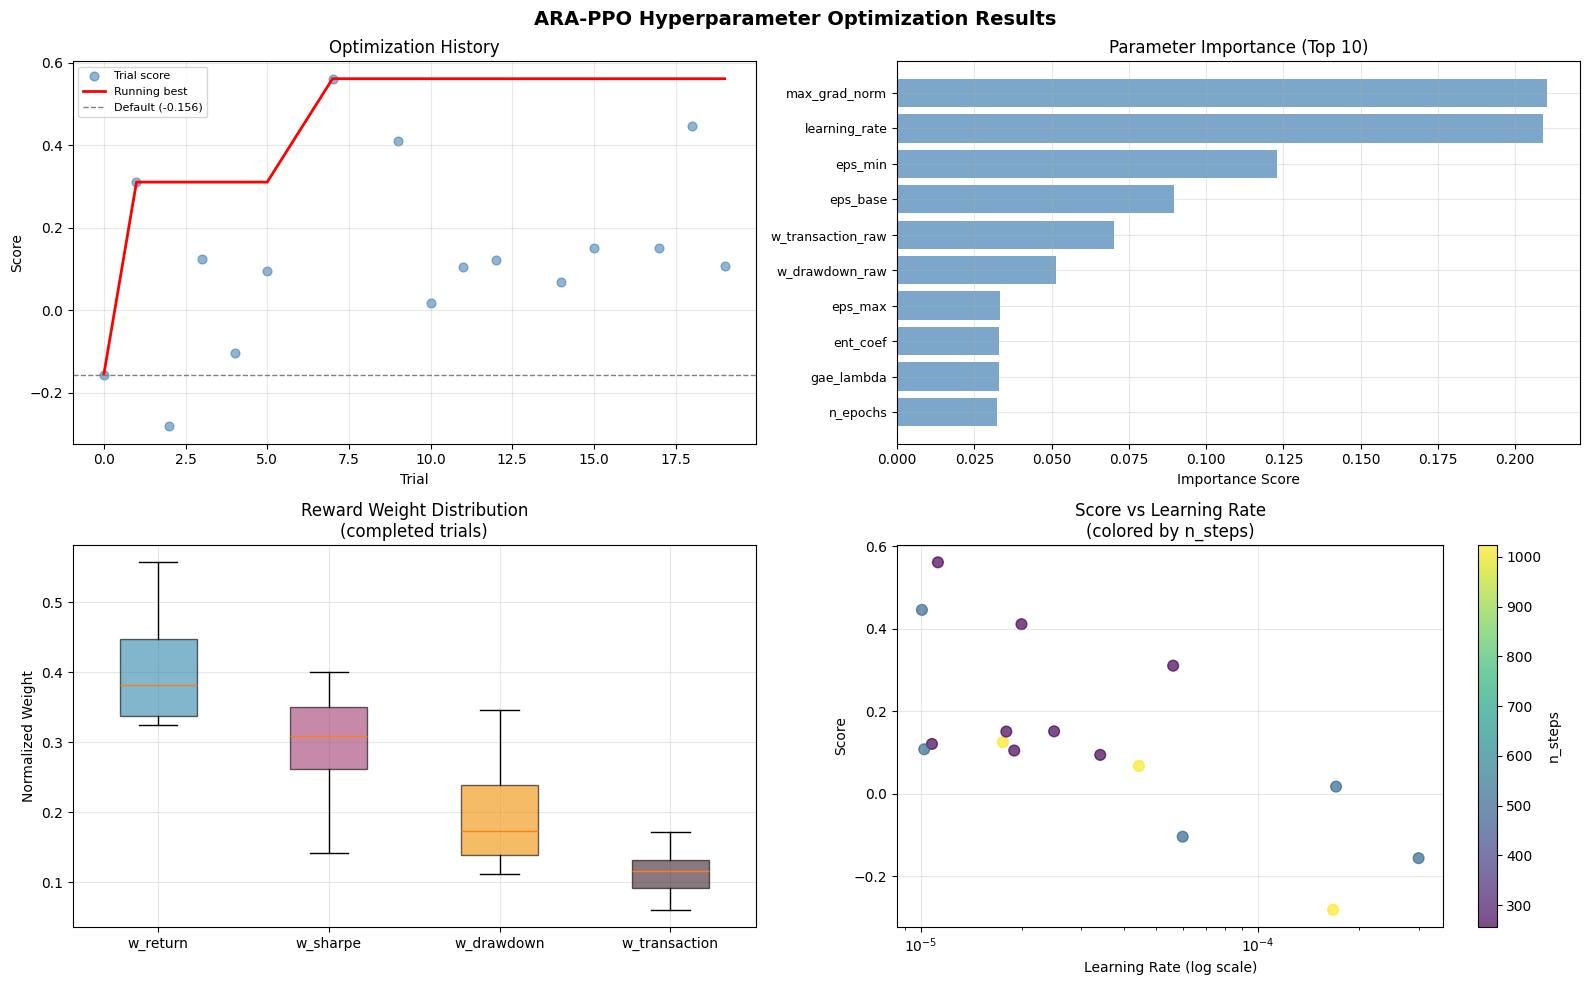

Saved → results/plots/hpo_analysis.png

--------------------------------------------------------------
Parameter                      Default         Best     Change
--------------------------------------------------------------
learning_rate                   0.0003    1.125e-05     -96.3% *
n_steps                            512          256
batch_size                          64           64
n_epochs                            10           12
gamma                             0.99       0.9662      -2.4%
gae_lambda                        0.95       0.9589      +0.9%
ent_coef                          0.01    0.0008765     -91.2% *
max_grad_norm                      0.5       0.9972     +99.4% *
eps_base                           0.2       0.2323     +16.2%
eps_alpha                          0.5       0.4544      -9.1%
eps_min                           0.05      0.04494     -10.1%
eps_max                            0.4       0.3387     -15.3%
w_return_raw                       0.4    

In [ ]:
# ── Optimization history plot ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('ARA-PPO Hyperparameter Optimization Results', fontsize=14, fontweight='bold')

completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
trial_nums = [t.number for t in completed]
trial_vals = [t.value  for t in completed]
running_best = [max(trial_vals[:i+1]) for i in range(len(trial_vals))]

ax = axes[0, 0]
ax.scatter(trial_nums, trial_vals, alpha=0.6, color='steelblue', s=40, label='Trial score')
ax.plot(trial_nums, running_best, color='red', linewidth=2, label='Running best')
if len(trial_vals) > 0:
    default_score = trial_vals[0] if trial_nums[0] == 0 else None
    if default_score is not None:
        ax.axhline(default_score, color='gray', linestyle='--', linewidth=1, label=f'Default ({default_score:.3f})')
ax.set_title('Optimization History')
ax.set_xlabel('Trial')
ax.set_ylabel('Score')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── Parameter importance ──────────────────────────────────────────────────
ax = axes[0, 1]
try:
    importance = optuna.importance.get_param_importances(study)
    top_params = list(importance.keys())[:10]
    top_vals   = [importance[p] for p in top_params]
    ax.barh(range(len(top_params)), top_vals, color='steelblue', alpha=0.7)
    ax.set_yticks(range(len(top_params)))
    ax.set_yticklabels(top_params, fontsize=9)
    ax.set_title('Parameter Importance (Top 10)')
    ax.set_xlabel('Importance Score')
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3)
except Exception as e:
    ax.text(0.5, 0.5, f'Importance unavailable:\n{e}', ha='center', va='center', transform=ax.transAxes)

# ── Reward weight distribution ────────────────────────────────────────────
ax = axes[1, 0]
weight_keys = ['w_return_raw', 'w_sharpe_raw', 'w_drawdown_raw', 'w_transaction_raw']
weight_labels = ['w_return', 'w_sharpe', 'w_drawdown', 'w_transaction']
weight_data = []
for t in completed:
    p = t.params
    total = sum(p.get(k, 0.25) for k in weight_keys)
    weight_data.append([p.get(k, 0.25)/total for k in weight_keys])
if weight_data:
    bp = ax.boxplot(list(zip(*weight_data)), labels=weight_labels, patch_artist=True)
    colors = ['#2E86AB', '#A23B72', '#F18F01', '#3B1F2B']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
ax.set_title('Reward Weight Distribution\n(completed trials)')
ax.set_ylabel('Normalized Weight')
ax.grid(True, alpha=0.3)

# ── Score vs learning rate ────────────────────────────────────────────────
ax = axes[1, 1]
if completed:
    lrs      = [t.params.get('learning_rate', 3e-4) for t in completed]
    scores   = [t.value for t in completed]
    n_steps_ = [t.params.get('n_steps', 512) for t in completed]
    scatter = ax.scatter(lrs, scores, c=n_steps_, cmap='viridis', s=60, alpha=0.7)
    plt.colorbar(scatter, ax=ax, label='n_steps')
    ax.set_xscale('log')
    ax.set_title('Score vs Learning Rate\n(colored by n_steps)')
    ax.set_xlabel('Learning Rate (log scale)')
    ax.set_ylabel('Score')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'hpo_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/plots/hpo_analysis.png')

# ── Best params comparison table ──────────────────────────────────────────
best_p = study.best_trial.params
defaults = {
    'learning_rate': 3e-4, 'n_steps': 512, 'batch_size': 64,
    'n_epochs': 10, 'gamma': 0.99, 'gae_lambda': 0.95,
    'ent_coef': 0.01, 'max_grad_norm': 0.5,
    'eps_base': 0.2, 'eps_alpha': 0.5, 'eps_min': 0.05, 'eps_max': 0.40,
    'w_return_raw': 0.40, 'w_sharpe_raw': 0.30,
    'w_drawdown_raw': 0.20, 'w_transaction_raw': 0.10,
}
print(f'\n{"-"*62}')
print(f'{"Parameter":<25} {"Default":>12} {"Best":>12} {"Change":>10}')
print(f'{"-"*62}')
for k, dv in defaults.items():
    bv = best_p.get(k, dv)
    if isinstance(dv, float) and dv != 0:
        pct = (bv - dv) / abs(dv) * 100
        flag = ' *' if abs(pct) > 20 else ''
        print(f'{k:<25} {dv:>12.4g} {bv:>12.4g} {pct:>+9.1f}%{flag}')
    else:
        print(f'{k:<25} {str(dv):>12} {str(bv):>12}')
print(f'{"-"*62}')
print('* = changed by more than 20% from default')


In [ ]:
best_p = study.best_trial.params

# ── Best PPO hparams ──────────────────────────────────────────────────────
best_ppo_hparams = {
    'learning_rate'      : best_p['learning_rate'],
    'n_steps'            : best_p['n_steps'],
    'batch_size'         : best_p['batch_size'],
    'n_epochs'           : best_p['n_epochs'],
    'gamma'              : best_p['gamma'],
    'gae_lambda'         : best_p['gae_lambda'],
    'ent_coef'           : best_p['ent_coef'],
    'max_grad_norm'      : best_p['max_grad_norm'],
    'clip_range'         : 0.2,
    'clip_range_vf'      : None,
    'normalize_advantage': True,
    'vf_coef'            : 0.5,
    'latent_dim'         : 256,
    'n_regime'           : 4,
    'actor_hidden'       : 128,
    'critic_hidden'      : 128,
    'dropout'            : 0.1,
    'eps_base'           : best_p['eps_base'],
    'eps_alpha'          : best_p['eps_alpha'],
    'eps_min'            : best_p['eps_min'],
    'eps_max'            : best_p['eps_max'],
}

# ── Best env config (normalized reward weights) ───────────────────────────
total_w = (best_p['w_return_raw'] + best_p['w_sharpe_raw'] +
           best_p['w_drawdown_raw'] + best_p['w_transaction_raw'])
best_env_config = {
    **ENV_CONFIG,
    'w_return'     : best_p['w_return_raw']      / total_w,
    'w_sharpe'     : best_p['w_sharpe_raw']      / total_w,
    'w_drawdown'   : best_p['w_drawdown_raw']    / total_w,
    'w_transaction': best_p['w_transaction_raw'] / total_w,
}

print('Best PPO hyperparameters:')
for k, v in best_ppo_hparams.items():
    print(f'  {k:<25}: {v}')
print('\nBest reward weights (normalized):')
print(f'  w_return      : {best_env_config["w_return"]:.4f}')
print(f'  w_sharpe      : {best_env_config["w_sharpe"]:.4f}')
print(f'  w_drawdown    : {best_env_config["w_drawdown"]:.4f}')
print(f'  w_transaction : {best_env_config["w_transaction"]:.4f}')
print(f'  sum           : {best_env_config["w_return"]+best_env_config["w_sharpe"]+best_env_config["w_drawdown"]+best_env_config["w_transaction"]:.4f}')


Best PPO hyperparameters:
  learning_rate            : 1.1248613366724763e-05
  n_steps                  : 256
  batch_size               : 64
  n_epochs                 : 12
  gamma                    : 0.9662147292485339
  gae_lambda               : 0.9589030964252582
  ent_coef                 : 0.0008764764861015512
  max_grad_norm            : 0.9972118925528495
  clip_range               : 0.2
  clip_range_vf            : None
  normalize_advantage      : True
  vf_coef                  : 0.5
  latent_dim               : 256
  n_regime                 : 4
  actor_hidden             : 128
  critic_hidden            : 128
  dropout                  : 0.1
  eps_base                 : 0.23230408393616414
  eps_alpha                : 0.45435558831672274
  eps_min                  : 0.04493539613485809
  eps_max                  : 0.33869593386733576

Best reward weights (normalized):
  w_return      : 0.4542
  w_sharpe      : 0.3473
  w_drawdown    : 0.1379
  w_transaction : 0.0606
  

Training best config for 50,000 steps on split 0...


Done in 183.2s

------------------------------------------------------------
Metric                  Pilot (default)   Best HPO  Improvement
------------------------------------------------------------
sharpe                          -1.4250     1.3681      +196.0%
total_return                    -0.0137     0.0198      +244.0%
max_drawdown                    -0.0183    -0.0087       +52.3%
calmar                          -0.9430     2.8602      +403.3%
sortino                         -2.3112     2.0303      +187.8%
------------------------------------------------------------


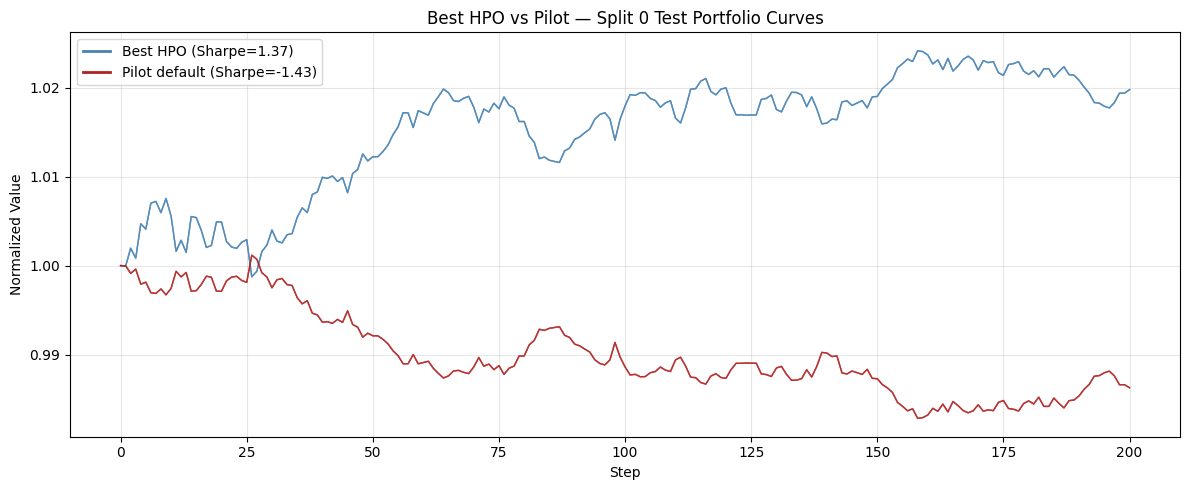

Saved → results/plots/hpo_best_vs_pilot.png


In [ ]:
# ── Train fresh model with best params ───────────────────────────────────
factory_best = WalkForwardEnvFactory(wti_df, ALL_FEATURES, WF_SPLITS, best_env_config)
train_best, test_best, _ = factory_best.get_split(0)

model_best, clip_best = make_ara_ppo(
    train_best, hparams=best_ppo_hparams,
    env_config=best_env_config, verbose=0
)
ep_cb_best = EpisodeMetricsCallback(verbose=0)

print('Training best config for 50,000 steps on split 0...')
t0 = time.time()
model_best.learn(
    total_timesteps=50_000,
    callback=[clip_best, ep_cb_best],
    progress_bar=True,
)
print(f'Done in {time.time()-t0:.1f}s')

# ── Evaluate best model ───────────────────────────────────────────────────
def eval_model(model, env, n_ep=5):
    metrics_list = []
    curves = []
    for ep in range(n_ep):
        obs, _ = env.reset(seed=ep)
        done = False
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, _, terminated, truncated, info = env.step(action)
            done = terminated or truncated
        m = env.get_episode_metrics()
        metrics_list.append(m)
        curves.append(env.value_history.copy())
    avg = {k: float(np.mean([m.get(k,0) for m in metrics_list])) for k in metrics_list[0]}
    avg['curves'] = curves
    return avg

best_metrics = eval_model(model_best, test_best, n_ep=5)

# ── Load pilot model for comparison ──────────────────────────────────────
pilot_path = MODELS_DIR / 'ara_ppo_split0_pilot.zip'
comparison_available = pilot_path.exists()

if comparison_available:
    factory_pilot = WalkForwardEnvFactory(wti_df, ALL_FEATURES, WF_SPLITS, ENV_CONFIG)
    _, test_pilot, _ = factory_pilot.get_split(0)
    model_pilot = PPO.load(str(pilot_path), device=DEVICE)
    pilot_metrics = eval_model(model_pilot, test_pilot, n_ep=5)

    # ── Comparison table ──────────────────────────────────────────────────
    print(f'\n{"-"*60}')
    print(f'{"Metric":<22} {"Pilot (default)":>16} {"Best HPO":>10} {"Improvement":>12}')
    print(f'{"-"*60}')
    for metric in ['sharpe', 'total_return', 'max_drawdown', 'calmar', 'sortino']:
        pv = pilot_metrics.get(metric, 0)
        bv = best_metrics.get(metric, 0)
        if pv != 0:
            imp = (bv - pv) / abs(pv) * 100
            print(f'{metric:<22} {pv:>16.4f} {bv:>10.4f} {imp:>+11.1f}%')
        else:
            print(f'{metric:<22} {pv:>16.4f} {bv:>10.4f} {"N/A":>12}')
    print(f'{"-"*60}')

    # ── Portfolio curve plot ──────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 5))
    for curve in best_metrics['curves']:
        arr = np.array(curve)
        ax.plot(arr/arr[0], alpha=0.4, color='steelblue', linewidth=1)
    for curve in pilot_metrics['curves']:
        arr = np.array(curve)
        ax.plot(arr/arr[0], alpha=0.4, color='firebrick', linewidth=1)
    ax.plot([], [], color='steelblue', linewidth=2, label=f'Best HPO (Sharpe={best_metrics["sharpe"]:.2f})')
    ax.plot([], [], color='firebrick', linewidth=2, label=f'Pilot default (Sharpe={pilot_metrics["sharpe"]:.2f})')
    ax.set_title('Best HPO vs Pilot — Split 0 Test Portfolio Curves')
    ax.set_xlabel('Step')
    ax.set_ylabel('Normalized Value')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'hpo_best_vs_pilot.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → results/plots/hpo_best_vs_pilot.png')
else:
    print(f'Pilot model not found at {pilot_path}. Skipping comparison.')
    print(f'Best model Sharpe: {best_metrics["sharpe"]:.4f}')
    print(f'Best model Return: {best_metrics["total_return"]:.4f}')


In [ ]:
# ── Save best model ──────────────────────────────────────────────────────
model_best.save(str(MODELS_DIR / 'ara_ppo_split0_best'))
print('Saved → models/ara_ppo_split0_best.zip')

# ── Save Optuna study ─────────────────────────────────────────────────────
joblib.dump(study, RESULTS_HPO / 'study.pkl')
print('Saved → results/hpo/study.pkl')

# ── Save best params JSON ─────────────────────────────────────────────────
with open(RESULTS_HPO / 'best_params.json', 'w') as f:
    json.dump(study.best_trial.params, f, indent=2)
print('Saved → results/hpo/best_params.json')

# ── Save best PPO hparams YAML ────────────────────────────────────────────
best_ppo_yaml = {k: (float(v) if isinstance(v, (np.floating, float)) else
                     int(v)   if isinstance(v, (np.integer, int)) else v)
                for k, v in best_ppo_hparams.items()}
with open(CONFIGS_DIR / 'best_ppo_hparams.yaml', 'w') as f:
    yaml.dump(best_ppo_yaml, f, default_flow_style=False)
print('Saved → configs/best_ppo_hparams.yaml')

# ── Save best env config YAML ─────────────────────────────────────────────
best_env_yaml = {k: (float(v) if isinstance(v, (np.floating, float)) else
                     int(v)   if isinstance(v, (np.integer, int)) else v)
                for k, v in best_env_config.items()}
with open(CONFIGS_DIR / 'best_env_config.yaml', 'w') as f:
    yaml.dump(best_env_yaml, f, default_flow_style=False)
print('Saved → configs/best_env_config.yaml')

# ── Save all trials CSV ───────────────────────────────────────────────────
trials_df = study.trials_dataframe()
trials_df.to_csv(RESULTS_HPO / 'all_trials.csv', index=False)
print('Saved → results/hpo/all_trials.csv')

# ── Final summary ─────────────────────────────────────────────────────────
print('\n' + '='*58)
print('NOTEBOOK 05 COMPLETE')
print('='*58)
print(f'Best trial   : #{study.best_trial.number}')
print(f'Best score   : {study.best_value:.4f}')
print(f'Best Sharpe  : {best_metrics["sharpe"]:.4f}')
print(f'Best Return  : {best_metrics["total_return"]:.4f}')
print(f'Best Max DD  : {best_metrics["max_drawdown"]:.4f}')
print('\nFiles ready for notebook 06:')
print('  configs/best_ppo_hparams.yaml')
print('  configs/best_env_config.yaml')
print('  models/ara_ppo_split0_best.zip')
print('\nNext: Run 06_evaluation_framework.ipynb')


Saved → models/ara_ppo_split0_best.zip
Saved → results/hpo/study.pkl
Saved → results/hpo/best_params.json
Saved → configs/best_ppo_hparams.yaml
Saved → configs/best_env_config.yaml
Saved → results/hpo/all_trials.csv

NOTEBOOK 05 COMPLETE
Best trial   : #7
Best score   : 0.5612
Best Sharpe  : 1.3681
Best Return  : 0.0198
Best Max DD  : -0.0087

Files ready for notebook 06:
  configs/best_ppo_hparams.yaml
  configs/best_env_config.yaml
  models/ara_ppo_split0_best.zip

Next: Run 06_evaluation_framework.ipynb


In [ ]:
import time

for lr in [5e-6, 2e-6, 1e-6]:
    factory = WalkForwardEnvFactory(wti_df, ALL_FEATURES, WF_SPLITS, best_env_config)
    train_env, test_env, _ = factory.get_split(0)
    
    test_hparams = {**best_ppo_hparams, 'learning_rate': lr}
    model_test, clip_cb = make_ara_ppo(train_env, hparams=test_hparams, verbose=0)
    
    t0 = time.time()
    model_test.learn(total_timesteps=50_000, callback=[clip_cb], progress_bar=False)
    
    sharpes = []
    for ep in range(3):
        obs, _ = test_env.reset(seed=ep)
        done = False
        while not done:
            action, _ = model_test.predict(obs, deterministic=True)
            obs, _, terminated, truncated, _ = test_env.step(action)
            done = terminated or truncated
        m = test_env.get_episode_metrics()
        sharpes.append(m['sharpe'])
    
    print(f'lr={lr:.0e}: Sharpe={np.mean(sharpes):.4f} | time={time.time()-t0:.0f}s')
    del model_test
    torch.cuda.empty_cache()
    gc.collect()

lr=5e-06: Sharpe=-0.9698 | time=185s
lr=2e-06: Sharpe=0.2787 | time=181s
lr=1e-06: Sharpe=1.0839 | time=180s
